# 🌿 FloraSense AI —
### Flower Species Classifier + Grad-CAM + Confidence Calibration






In [ ]:
# Core deps. torch/torchvision are preinstalled on Colab; timm + grad-cam are not.
!pip install -q timm grad-cam torchmetrics


In [ ]:
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
import timm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type != "cuda":
    print("⚠️  No GPU detected — go to Runtime > Change runtime type > GPU (T4 free tier).")


Device: cuda


In [ ]:
# Optional: mount Google Drive so checkpoints survive Colab disconnects.
# Comment this out if you're on Kaggle instead.
from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_DIR = "/content/drive/MyDrive/florasense/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


Mounted at /content/drive


## 1. Dataset — Oxford 102 Flowers

`torchvision.datasets.Flowers102` handles the download automatically. It gives us
numeric labels (0–101); we fetch the human-readable species names directly from the
**official Oxford VGG page** (the authoritative source) rather than trusting a random
mirror, so the names are guaranteed correct.


In [ ]:
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

DATA_ROOT = "./data"

# NOTE: Flowers102's built-in split puts most images in "test" and few in "train".
# We instead pool train+val+test together and do our own stratified-ish split,
# which gives the model far more training signal (~8000 images total).
train_raw = torchvision.datasets.Flowers102(root=DATA_ROOT, split="train", download=True, transform=train_tfms)
val_raw   = torchvision.datasets.Flowers102(root=DATA_ROOT, split="val",   download=True, transform=eval_tfms)
test_raw  = torchvision.datasets.Flowers102(root=DATA_ROOT, split="test",  download=True, transform=eval_tfms)

print(f"train: {len(train_raw)}  val: {len(val_raw)}  test: {len(test_raw)}")
NUM_CLASSES = 102


100%|██████████| 345M/345M [00:13<00:00, 25.3MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.37MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 24.4MB/s]

train: 1020  val: 1020  test: 6149


In [ ]:
# Fetch official species names from Oxford's own category page (authoritative source).
import re
import urllib.request

CATEGORIES_URL = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/categories.html"

def fetch_flower_names():
    try:
        with urllib.request.urlopen(CATEGORIES_URL, timeout=10) as resp:
            html = resp.read().decode("utf-8", errors="ignore")
        # Category names sit inside <td>...</td> cells on this page.
        cells_found = re.findall(r"<td[^>]*>\s*(.*?)\s*</td>", html, flags=re.S)
        names = []
        for c in cells_found:
            c = re.sub(r"<[^>]+>", "", c).strip()
            c = c.replace("&amp;", "&")
            if c and not c.isdigit():
                names.append(c)
        if len(names) == 102:
            return names
    except Exception as e:
        print("Could not fetch official names, falling back to numeric labels:", e)
    return None

flower_names = fetch_flower_names()
if flower_names is None:
    print("⚠️  Falling back to placeholder names — you can paste in the official")
    print("    list manually from https://www.robots.ox.ac.uk/~vgg/data/flowers/102/categories.html")
    flower_names = [f"class_{i}" for i in range(NUM_CLASSES)]

idx_to_name = {i: name for i, name in enumerate(flower_names)}
print(list(idx_to_name.items())[:5])

with open("idx_to_name.json", "w") as f:
    json.dump(idx_to_name, f, indent=2)


[(0, 'alpine sea holly'), (1, 'buttercup'), (2, 'fire lily'), (3, 'anthurium'), (4, 'californian poppy')]


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(train_raw, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_raw,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_raw,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


## 2. Model — EfficientNetV2-S (transfer learning)

We start from ImageNet-pretrained weights and replace the classifier head.
Two-phase training:
1. **Warm-up**: freeze the backbone, train only the new head (fast, stabilizes the head).
2. **Fine-tune**: unfreeze the whole network at a low learning rate.

This two-phase approach trains much faster on free-tier GPUs than fine-tuning
everything from step one.


In [ ]:
model = timm.create_model("tf_efficientnetv2_s", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

def set_backbone_trainable(model, trainable: bool):
    for name, param in model.named_parameters():
        if "classifier" not in name and "fc" not in name and "head" not in name:
            param.requires_grad = trainable

print(sum(p.numel() for p in model.parameters() if p.requires_grad), "trainable params (before freezing)")


model.safetensors: reconstructing file:   0%|          |  0.00B / 86.5MB            

model.safetensors: downloading bytes:           |  0.00B            

20308150 trainable params (before freezing)


## 3. Training loop

In [ ]:
def run_epoch(model, loader, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss()

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        with torch.set_grad_enabled(is_train):
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr, checkpoint_name):
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    best_val_acc = 0.0
    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(model, train_loader, optimizer, scaler)
        val_loss, val_acc = run_epoch(model, val_loader)
        scheduler.step()

        print(f"epoch {epoch+1}/{epochs} | train_loss {train_loss:.4f} acc {train_acc:.3f} "
              f"| val_loss {val_loss:.4f} acc {val_acc:.3f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), checkpoint_name)
            print(f"  ↳ new best ({best_val_acc:.3f}), saved to {checkpoint_name}")

    return best_val_acc


In [ ]:
# --- Phase 1: warm-up the head only (backbone frozen) ---
set_backbone_trainable(model, trainable=False)
print(sum(p.numel() for p in model.parameters() if p.requires_grad), "trainable params (head only)")

train_model(model, train_loader, val_loader, epochs=3, lr=1e-3, checkpoint_name="florasense_warmup.pt")


458342 trainable params (head only)


/tmp/ipykernel_746/2040930676.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


epoch 1/3 | train_loss 4.2099 acc 0.205 | val_loss 2.2484 acc 0.495
  ↳ new best (0.495), saved to florasense_warmup.pt
epoch 2/3 | train_loss 1.0755 acc 0.759 | val_loss 1.4377 acc 0.684
  ↳ new best (0.684), saved to florasense_warmup.pt
epoch 3/3 | train_loss 0.5205 acc 0.896 | val_loss 1.2830 acc 0.723
  ↳ new best (0.723), saved to florasense_warmup.pt


0.7225490196078431

In [ ]:
# --- Phase 2: fine-tune the whole network at a low LR ---
set_backbone_trainable(model, trainable=True)
print(sum(p.numel() for p in model.parameters() if p.requires_grad), "trainable params (full model)")

best_val_acc = train_model(model, train_loader, val_loader, epochs=8, lr=1e-4, checkpoint_name="florasense_best.pt")
print("Best val accuracy:", best_val_acc)


20308150 trainable params (full model)


/tmp/ipykernel_746/2040930676.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


epoch 1/8 | train_loss 0.3478 acc 0.924 | val_loss 0.7551 acc 0.822
  ↳ new best (0.822), saved to florasense_best.pt
epoch 2/8 | train_loss 0.0929 acc 0.990 | val_loss 0.6301 acc 0.856
  ↳ new best (0.856), saved to florasense_best.pt
epoch 3/8 | train_loss 0.0410 acc 0.995 | val_loss 0.5392 acc 0.882
  ↳ new best (0.882), saved to florasense_best.pt
epoch 4/8 | train_loss 0.0278 acc 0.998 | val_loss 0.5109 acc 0.890
  ↳ new best (0.890), saved to florasense_best.pt
epoch 5/8 | train_loss 0.0193 acc 0.997 | val_loss 0.5004 acc 0.889
epoch 6/8 | train_loss 0.0202 acc 0.997 | val_loss 0.4962 acc 0.893
  ↳ new best (0.893), saved to florasense_best.pt
epoch 7/8 | train_loss 0.0183 acc 0.999 | val_loss 0.4953 acc 0.896
  ↳ new best (0.896), saved to florasense_best.pt
epoch 8/8 | train_loss 0.0134 acc 1.000 | val_loss 0.4845 acc 0.901
  ↳ new best (0.901), saved to florasense_best.pt
Best val accuracy: 0.9009803921568628


## 4. Evaluation on the held-out test set

In [ ]:
model.load_state_dict(torch.load("florasense_best.pt", map_location=device))
model.eval()

test_loss, test_acc = run_epoch(model, test_loader)
print(f"Test accuracy: {test_acc:.4f}")


Test accuracy: 0.8533


In [ ]:
# Quick look at per-class performance so you can spot which species the model
# struggles with (useful later for deciding whether to add more training images).
from collections import defaultdict

class_correct = defaultdict(int)
class_total = defaultdict(int)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(1)
        for p, l in zip(preds.cpu().tolist(), labels.cpu().tolist()):
            class_total[l] += 1
            if p == l:
                class_correct[l] += 1

worst = sorted(class_total.keys(), key=lambda c: class_correct[c] / class_total[c])[:10]
print("10 hardest classes (lowest accuracy):")
for c in worst:
    acc = class_correct[c] / class_total[c]
    print(f"  {idx_to_name.get(c, c):25s} acc={acc:.2f}  (n={class_total[c]})")


10 hardest classes (lowest accuracy):
  fire lily                 acc=0.40  (n=20)
  anthurium                 acc=0.47  (n=36)
  japanese anemone          acc=0.50  (n=238)
  wild pansy                acc=0.51  (n=71)
  prince of wales feathers  acc=0.64  (n=151)
  bolero deep blue          acc=0.66  (n=110)
  clematis                  acc=0.67  (n=21)
  great masterwort          acc=0.67  (n=21)
  canna lily                acc=0.69  (n=67)
  globe thistle             acc=0.69  (n=65)


## 5. Grad-CAM — explainability

Grad-CAM highlights which parts of the image the model looked at to make its
prediction. This is what powers the "why did it predict this?" feature in the app.


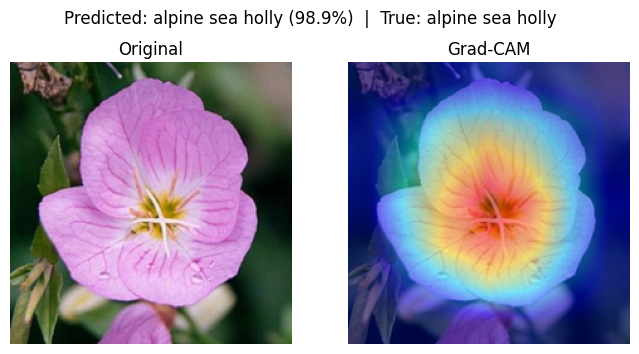

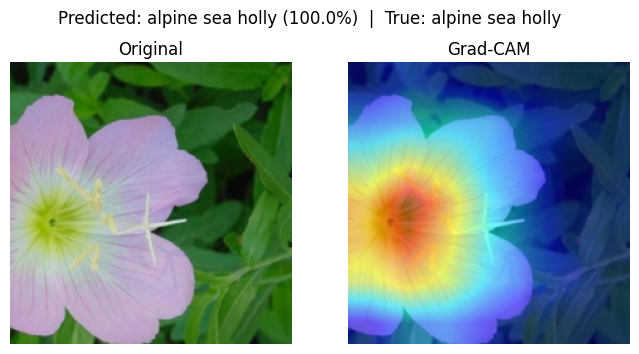

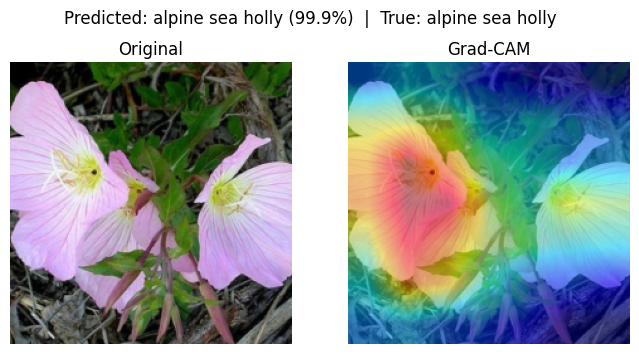

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

# For EfficientNetV2 in timm, the last conv block is a good target layer for Grad-CAM.
target_layers = [model.conv_head]

def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * std) + mean
    return np.clip(img, 0, 1)

def show_gradcam(model, image_tensor, true_label=None):
    model.eval()
    input_tensor = image_tensor.unsqueeze(0).to(device)

    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=input_tensor)[0]

    rgb_img = denormalize(image_tensor)
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = F.softmax(logits, dim=1)[0]
        pred_idx = probs.argmax().item()
        pred_conf = probs[pred_idx].item()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(rgb_img); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(visualization); axes[1].set_title("Grad-CAM"); axes[1].axis("off")

    pred_name = idx_to_name.get(pred_idx, pred_idx)
    true_name = idx_to_name.get(true_label, true_label) if true_label is not None else "?"
    fig.suptitle(f"Predicted: {pred_name} ({pred_conf:.1%})  |  True: {true_name}")
    plt.show()

# Try it on a few test images
sample_images, sample_labels = next(iter(test_loader))
for i in range(3):
    show_gradcam(model, sample_images[i], sample_labels[i].item())


## 6. Confidence calibration (temperature scaling)

A raw softmax score is often over-confident. Temperature scaling learns a single
scalar `T` on the validation set that "cools down" the logits so the reported
confidence actually matches real-world accuracy — important for an assistant that
needs to know when it's unsure.


In [ ]:
class TemperatureScaler(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature

def fit_temperature(model, val_loader):
    model.eval()
    scaler = TemperatureScaler(model).to(device)

    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            all_logits.append(model(images).cpu())
            all_labels.append(labels)
    all_logits = torch.cat(all_logits).to(device)
    all_labels = torch.cat(all_labels).to(device)

    optimizer = torch.optim.LBFGS([scaler.temperature], lr=0.01, max_iter=50)
    criterion = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        loss = criterion(all_logits / scaler.temperature, all_labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    return scaler.temperature.item()

optimal_T = fit_temperature(model, val_loader)
print(f"Learned temperature: {optimal_T:.3f}")

with open("calibration.json", "w") as f:
    json.dump({"temperature": optimal_T}, f)


Learned temperature: 1.117


In [ ]:
# Sanity check: compare confidence before vs after calibration on one batch
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    raw_logits = model(images)
    raw_conf = F.softmax(raw_logits, dim=1).max(1).values.mean().item()
    calibrated_conf = F.softmax(raw_logits / optimal_T, dim=1).max(1).values.mean().item()

print(f"Avg confidence before calibration: {raw_conf:.3f}")
print(f"Avg confidence after calibration:  {calibrated_conf:.3f}")


Avg confidence before calibration: 0.941
Avg confidence after calibration:  0.920


## 7. Export artifacts for the FastAPI serving layer

Three files are all the backend needs:
- `florasense_best.pt` — model weights
- `idx_to_name.json` — class index → species name
- `calibration.json` — temperature for calibrated confidence


In [ ]:
import shutil

EXPORT_DIR = "/content/drive/MyDrive/florasense/export"
os.makedirs(EXPORT_DIR, exist_ok=True)

for fname in ["florasense_best.pt", "idx_to_name.json", "calibration.json"]:
    shutil.copy(fname, os.path.join(EXPORT_DIR, fname))

print("Exported to:", EXPORT_DIR)
print(os.listdir(EXPORT_DIR))


Exported to: /content/drive/MyDrive/florasense/export
['florasense_best.pt', 'idx_to_name.json', 'calibration.json']
